In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# GPU-based RAPIDS modules
from cuml.preprocessing import StandardScaler
from cuml.svm import SVC as cuSVC
from itertools import product
from imblearn.over_sampling import SMOTE

In [ ]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("creditcard.csv")
# Optional: downsample for testing
# df = df.sample(frac=0.1, random_state=42)

X = df.drop("Class", axis=1)
y = df["Class"]

# -----------------------------
# Global configuration
# -----------------------------
TEST_SIZE = 0.2
RANDOM_STATE = 42
SVM_RANDOM_STATE = 42
SVM_N_ITER = 5
KFOLD_SPLITS = 5
CUSTOM_THRESH = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# -----------------------------
# Search space (simplified for stability)
# -----------------------------
SVM_PARAM_SPACE = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale"],
    "class_weight": [None, "balanced"],
    "tol": [1e-3],
}

np.random.seed(SVM_RANDOM_STATE)
random.seed(SVM_RANDOM_STATE)

In [ ]:
# =========================================================
# Cross-validation on GPU
# =========================================================
def cross_validate_gpu(pipeline_builder, X, y, kfold):
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

        pipeline = pipeline_builder()
        pipeline.fit(Xtr, ytr)
        preds = pipeline.decision_function(Xval)
        auc_score = roc_auc_score(yval, preds)
        print(f"    Fold {fold}: ROC-AUC = {auc_score:.4f}")
        scores.append(auc_score)
    return np.mean(scores), np.std(scores)

# =========================================================
# Evaluation
# =========================================================
def evaluate_gpu(model, X_test, y_test, label="Model", threshold=0.3):
    y_prob = model.decision_function(X_test)
    y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

    print(f"\n{label} — Evaluation Metrics")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"PR-AUC Score:  {pr_auc:.4f}")
    print(f"Optimal Threshold (by F1): {thresholds[np.argmax(f1)]:.3f}  (F1={np.max(f1):.3f})")

    # --- Diagnostic plots ---
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix — {label}')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],"--",color='grey')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title(f"ROC Curve — {label}")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.title(f"PR Curve — {label}")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1[:-1])
    plt.xlabel("Threshold"); plt.ylabel("F1"); plt.title(f"F1 vs Threshold — {label}")
    plt.tight_layout(); plt.show()

    return {
        "model": label,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": thresholds[np.argmax(f1)],
        "confusion_matrix": cm,
        "classification_report": classification_report(y_test, y_pred, digits=4, output_dict=True)
    }

# =========================================================
# Build GPU SVM pipeline
# =========================================================
def build_gpu_svm(C=1.0, kernel="rbf", class_weight=None, gamma="scale", tol=1e-3):
    print(f"Building GPU SVM: C={C}, kernel={kernel}, gamma={gamma}, tol={tol}, class_weight={class_weight}")
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", cuSVC(
            C=C, kernel=kernel, gamma=gamma, tol=tol,
            class_weight=None if class_weight == "smote_class_weight" else class_weight,
            probability=False, random_state=RANDOM_STATE
        ))
    ])

# =========================================================
# Random search for GPU SVM
# =========================================================
def random_search_gpu_svm(X_train, y_train, kfold, n_iter=8):
    all_combos = list(product(
        SVM_PARAM_SPACE["C"],
        SVM_PARAM_SPACE["kernel"],
        SVM_PARAM_SPACE["gamma"],
        SVM_PARAM_SPACE["class_weight"],
        SVM_PARAM_SPACE["tol"]
    ))
    sampled = random.sample(all_combos, min(n_iter, len(all_combos)))

    best_score, best_params, best_builder = -1, None, None
    print("\n============================================================")
    print("GPU SVM RANDOM SEARCH STARTED")
    print("============================================================\n")

    for C, kernel, gamma, cw, tol in sampled:
        print(f"  Testing C={C}, kernel={kernel}, gamma={gamma}, class_weight={cw}, tol={tol}")
        builder = lambda: build_gpu_svm(C=C, kernel=kernel, gamma=gamma, class_weight=cw, tol=tol)
        mean_cv, std_cv = cross_validate_gpu(builder, X_train, y_train, kfold)
        print(f"    CV ROC-AUC: {mean_cv:.4f} ± {std_cv:.4f}\n")
        if mean_cv > best_score:
            best_score, best_params, best_builder = mean_cv, {"C":C,"kernel":kernel,"gamma":gamma,"class_weight":cw,"tol":tol}, builder

    print(f"\nBest Parameters Found: {best_params}, ROC-AUC={best_score:.4f}")
    final_model = best_builder(); final_model.fit(X_train, y_train)
    return final_model, best_params

# =========================================================
# Training entry point
# =========================================================
def train_gpu_svm(X_train, y_train, X_test, y_test, custom_threshold=0.3, balance_method="none"):
    print("==============================================")
    print(f"GPU SVM TRAINING STARTED ({balance_method.upper()})")
    print("==============================================")

    kfold = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # Handle balancing
    if balance_method in ["smote", "smote_class_weight"]:
        print(f"Applying {balance_method.upper()} balancing (partial)...")
        sm = SMOTE(sampling_strategy=0.2, random_state=RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    cw_setting = None
    if balance_method == "class_weight":
        cw_setting = "balanced"
    elif balance_method == "smote_class_weight":
        cw_setting = None

    final_model, best_params = random_search_gpu_svm(X_train, y_train, kfold, n_iter=SVM_N_ITER)
    print(f"\nBest Parameters for {balance_method.upper()}: {best_params}")
    print("\nEvaluating on Test Set...")

    metrics = evaluate_gpu(final_model, X_test, y_test, label=f"GPU SVM ({balance_method.upper()})", threshold=custom_threshold)
    metrics["best_params"] = best_params
    return final_model, best_params, metrics

GPU SVM TRAINING STARTED (NONE)

GPU SVM RANDOM SEARCH STARTED

  Testing C=10, kernel=rbf, gamma=scale, class_weight=None, tol=0.001
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 1: ROC-AUC = 0.9762
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 2: ROC-AUC = 0.9549
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 3: ROC-AUC = 0.9462
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 4: ROC-AUC = 0.9753
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 5: ROC-AUC = 0.9459
    CV ROC-AUC: 0.9597 ± 0.0135

  Testing C=0.1, kernel=linear, gamma=scale, class_weight=balanced, tol=0.001
Building GPU SVM: C=0.1, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
[2025-10-14 06:00:59.544] [CUML] [warning] SVC with the linear kernel can be much faster using the specialized solver provided by Line

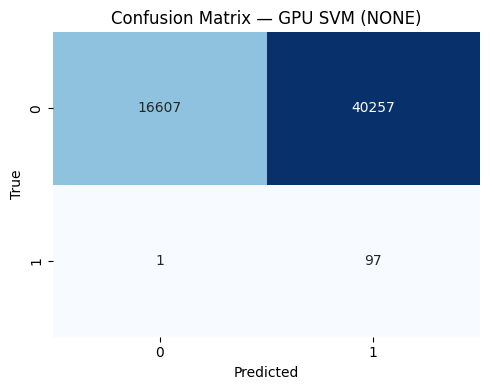

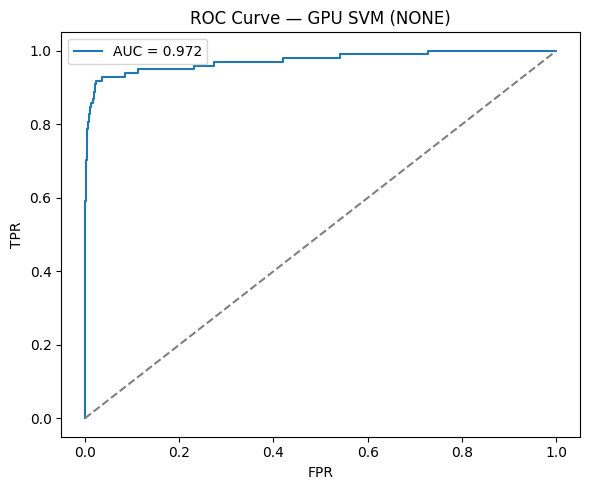

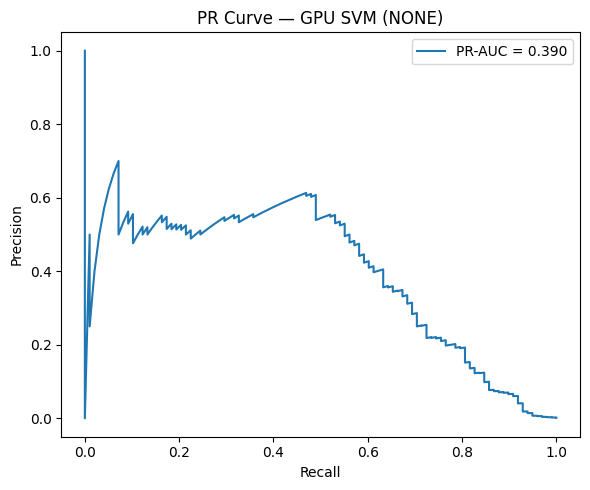

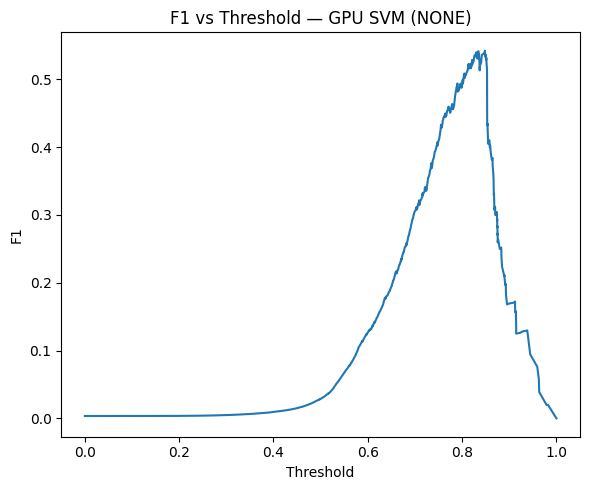

In [ ]:
# ================================================
# RUN 1 — NO BALANCING
# ================================================
svm_none_model, svm_none_params, svm_none_metrics = train_gpu_svm(X_train, y_train, X_test, y_test, balance_method="none")

GPU SVM TRAINING STARTED (CLASS_WEIGHT)

GPU SVM RANDOM SEARCH STARTED

  Testing C=0.1, kernel=rbf, gamma=scale, class_weight=balanced, tol=0.001
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 1: ROC-AUC = 0.9910
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 2: ROC-AUC = 0.9706
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 3: ROC-AUC = 0.9681
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 4: ROC-AUC = 0.9813
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 5: ROC-AUC = 0.9706
    CV ROC-AUC: 0.9763 ± 0.0086

  Testing C=0.1, kernel=rbf, gamma=scale, class_weight=None, tol=0.001
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 1: ROC-AUC = 0.9626
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
  

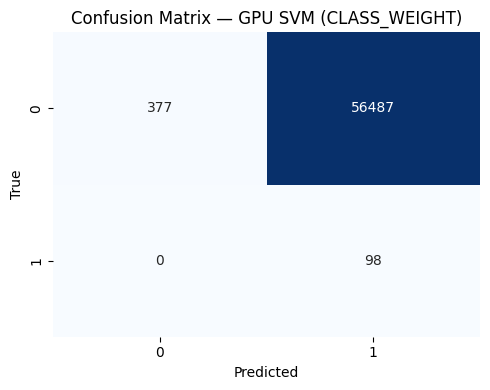

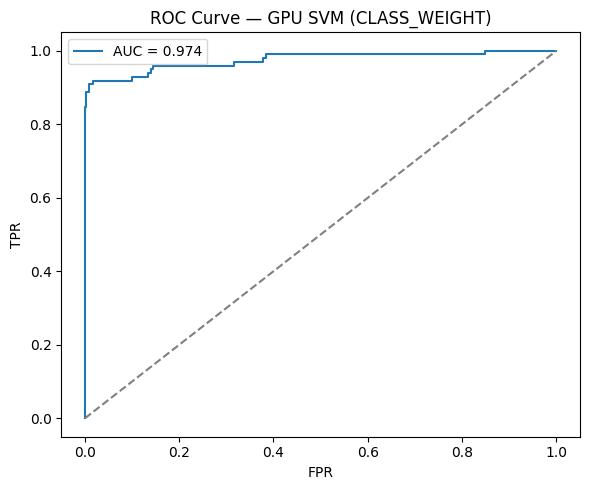

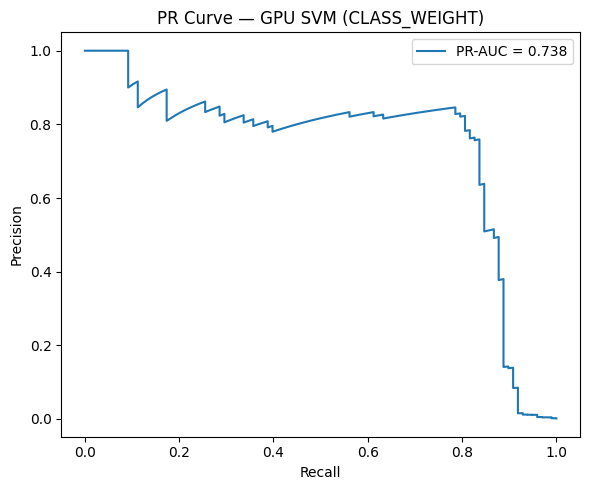

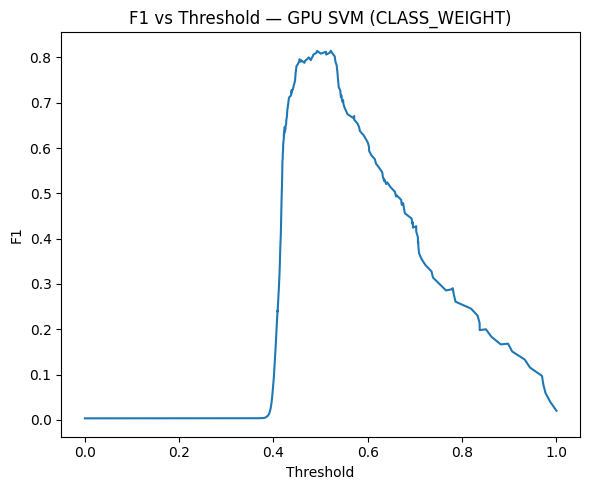

In [ ]:
# ================================================
# RUN 2 — CLASS WEIGHT
# ================================================
svm_cw_model, svm_cw_params, svm_cw_metrics = train_gpu_svm(X_train, y_train, X_test, y_test, balance_method="class_weight")

GPU SVM TRAINING STARTED (SMOTE)
Applying SMOTE balancing (partial)...

GPU SVM RANDOM SEARCH STARTED

  Testing C=10, kernel=linear, gamma=scale, class_weight=balanced, tol=0.001
Building GPU SVM: C=10, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
    Fold 1: ROC-AUC = 0.9979
Building GPU SVM: C=10, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
    Fold 2: ROC-AUC = 0.9978
Building GPU SVM: C=10, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
    Fold 3: ROC-AUC = 0.9976
Building GPU SVM: C=10, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
    Fold 4: ROC-AUC = 0.9979
Building GPU SVM: C=10, kernel=linear, gamma=scale, tol=0.001, class_weight=balanced
    Fold 5: ROC-AUC = 0.9982
    CV ROC-AUC: 0.9979 ± 0.0002

  Testing C=1, kernel=rbf, gamma=scale, class_weight=None, tol=0.001
Building GPU SVM: C=1, kernel=rbf, gamma=scale, tol=0.001, class_weight=None
    Fold 1: ROC-AUC = 0.9998
Building GPU SVM: C=1, kernel=rbf, gamma=s

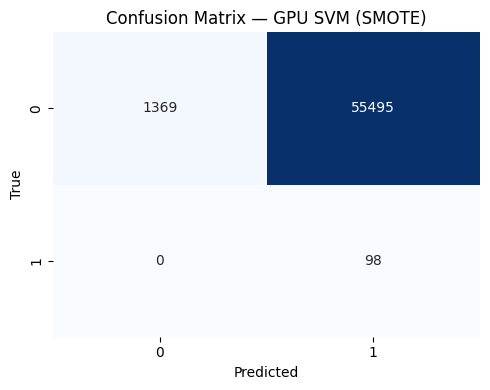

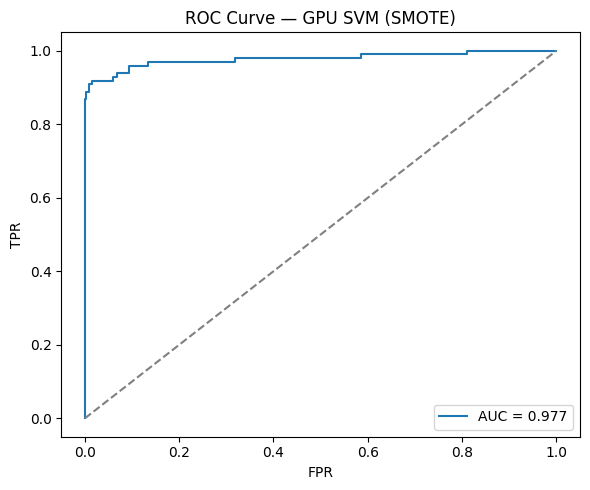

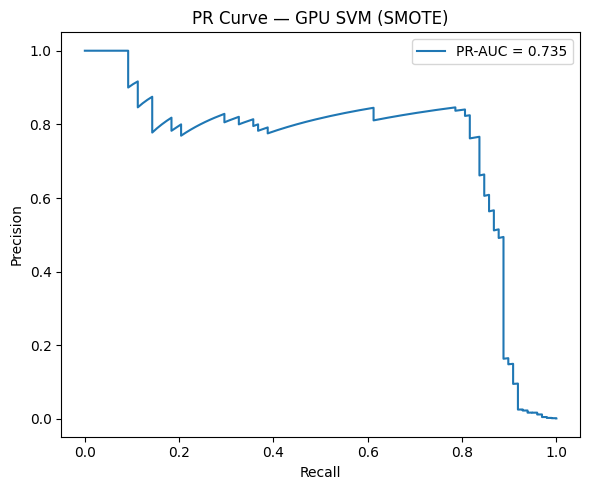

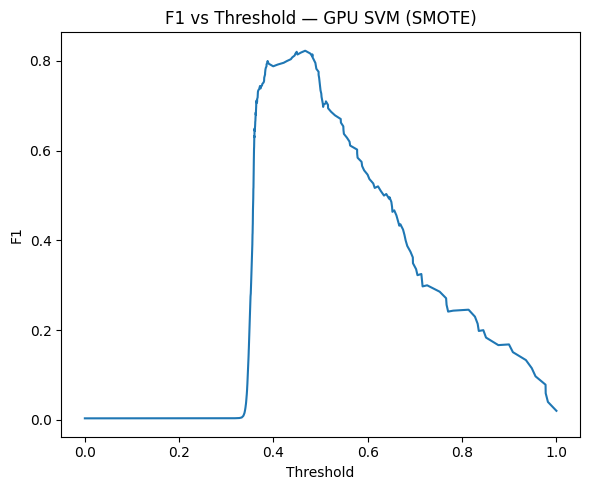

In [ ]:
# ================================================
# RUN 3 — SMOTE
# ================================================
svm_smote_model, svm_smote_params, svm_smote_metrics = train_gpu_svm(X_train, y_train, X_test, y_test, balance_method="smote")

GPU SVM TRAINING STARTED (SMOTE_CLASS_WEIGHT)
Applying SMOTE_CLASS_WEIGHT balancing (partial)...

GPU SVM RANDOM SEARCH STARTED

  Testing C=0.1, kernel=rbf, gamma=scale, class_weight=balanced, tol=0.001
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 1: ROC-AUC = 0.9994
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 2: ROC-AUC = 0.9995
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 3: ROC-AUC = 0.9995
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 4: ROC-AUC = 0.9995
Building GPU SVM: C=0.1, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 5: ROC-AUC = 0.9995
    CV ROC-AUC: 0.9995 ± 0.0000

  Testing C=10, kernel=rbf, gamma=scale, class_weight=balanced, tol=0.001
Building GPU SVM: C=10, kernel=rbf, gamma=scale, tol=0.001, class_weight=balanced
    Fold 1: ROC-AUC = 0.9999
Building GPU SVM: 

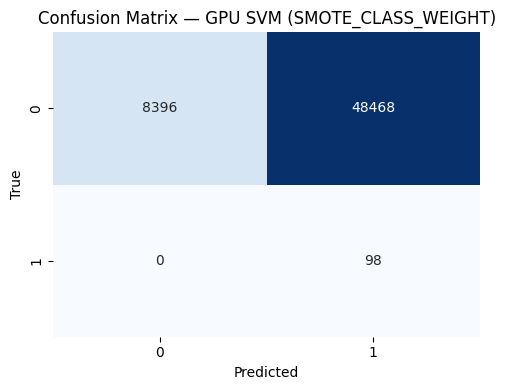

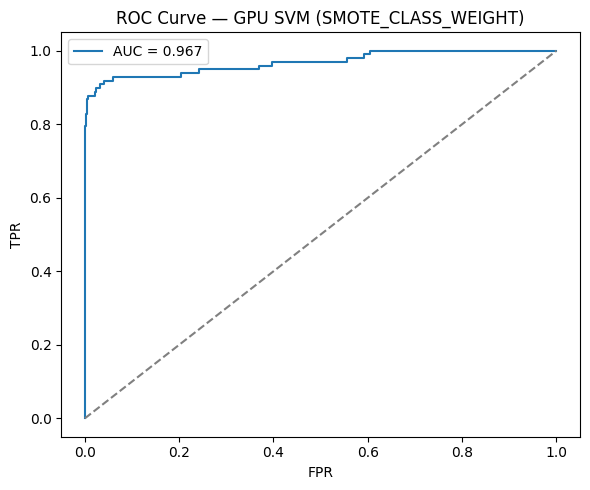

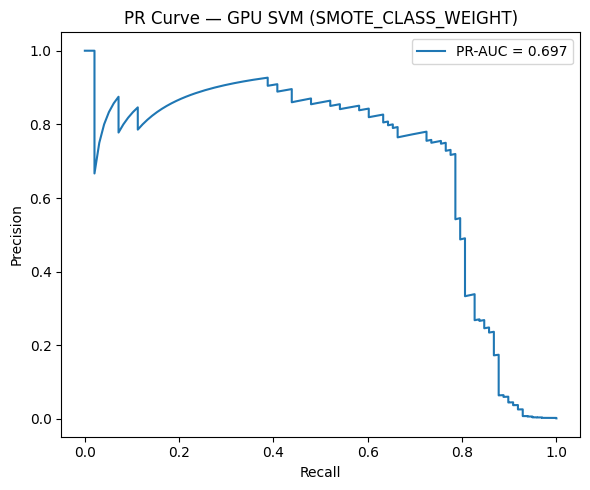

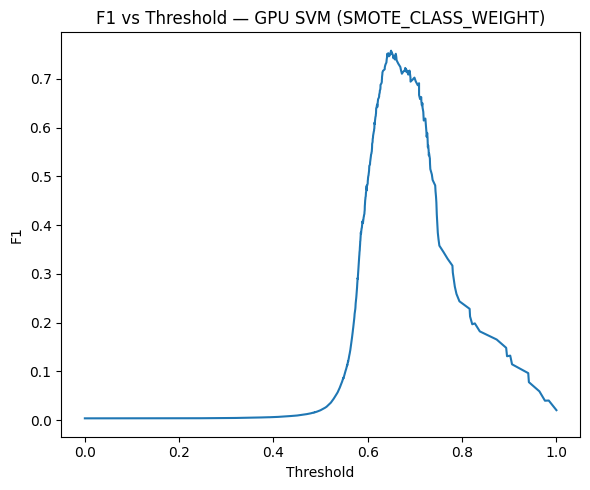

In [ ]:
# ================================================
# RUN 4 — SMOTE + CLASS_WEIGHT
# ================================================
svm_hybrid_model, svm_hybrid_params, svm_hybrid_metrics = train_gpu_svm(X_train, y_train, X_test, y_test, balance_method="smote_class_weight")

In [ ]:
# =========================================================
# Results Summary
# =========================================================
results_df = pd.DataFrame([
    {"Model": "SVM — None", "ROC-AUC": svm_none_metrics["roc_auc"], "PR-AUC": svm_none_metrics["pr_auc"], "Best Params": svm_none_metrics["best_params"]},
    {"Model": "SVM — Class Weight", "ROC-AUC": svm_cw_metrics["roc_auc"], "PR-AUC": svm_cw_metrics["pr_auc"], "Best Params": svm_cw_metrics["best_params"]},
    {"Model": "SVM — SMOTE", "ROC-AUC": svm_smote_metrics["roc_auc"], "PR-AUC": svm_smote_metrics["pr_auc"], "Best Params": svm_smote_metrics["best_params"]},
    {"Model": "SVM — SMOTE + Class Weight", "ROC-AUC": svm_hybrid_metrics["roc_auc"], "PR-AUC": svm_hybrid_metrics["pr_auc"], "Best Params": svm_hybrid_metrics["best_params"]}
])
print("\n================== GPU SVM RESULTS ==================")
print(results_df.to_string(index=False))


================== GPU SVM RESULTS ==================
                     Model  ROC-AUC   PR-AUC                                                                                Best Params
                SVM — None 0.972489 0.390368 {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.001}
        SVM — Class Weight 0.974455 0.738012 {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.001}
               SVM — SMOTE 0.977393 0.735116     {'C': 10, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.001}
SVM — SMOTE + Class Weight 0.967482 0.697297           {'C': 10, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None, 'tol': 0.001}
